# Housing Data Exploration

This notebook explores the variables in the Housing dataset.

In [2]:
# ...existing code...
import requests
import time
# ...existing code...

def call_api(method: str, base_url: str, path: str, payload: dict | None = None, params: dict | None = None):
    """Execute a backend API request and normalize response handling for UI rendering."""
    target_url = f"{base_url.rstrip('/')}{path}"
    retries = 2
    backoff_seconds = 1.5

    for attempt in range(retries + 1):
        try:
            response = requests.request(
                method=method,
                url=target_url,
                json=payload,
                params=params,
                timeout=20,
            )
            try:
                body = response.json()
            except ValueError:
                body = {"raw": response.text}
            return response.status_code, body, target_url
        except requests.RequestException as exc:
            if attempt < retries:
                time.sleep(backoff_seconds * (attempt + 1))
                continue
            return None, {"error": str(exc)}, target_url
# ...existing code...

Housing Data Exploration

Dataset shape: (21613, 21)
Rows: 21613, Columns: 21
<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat      

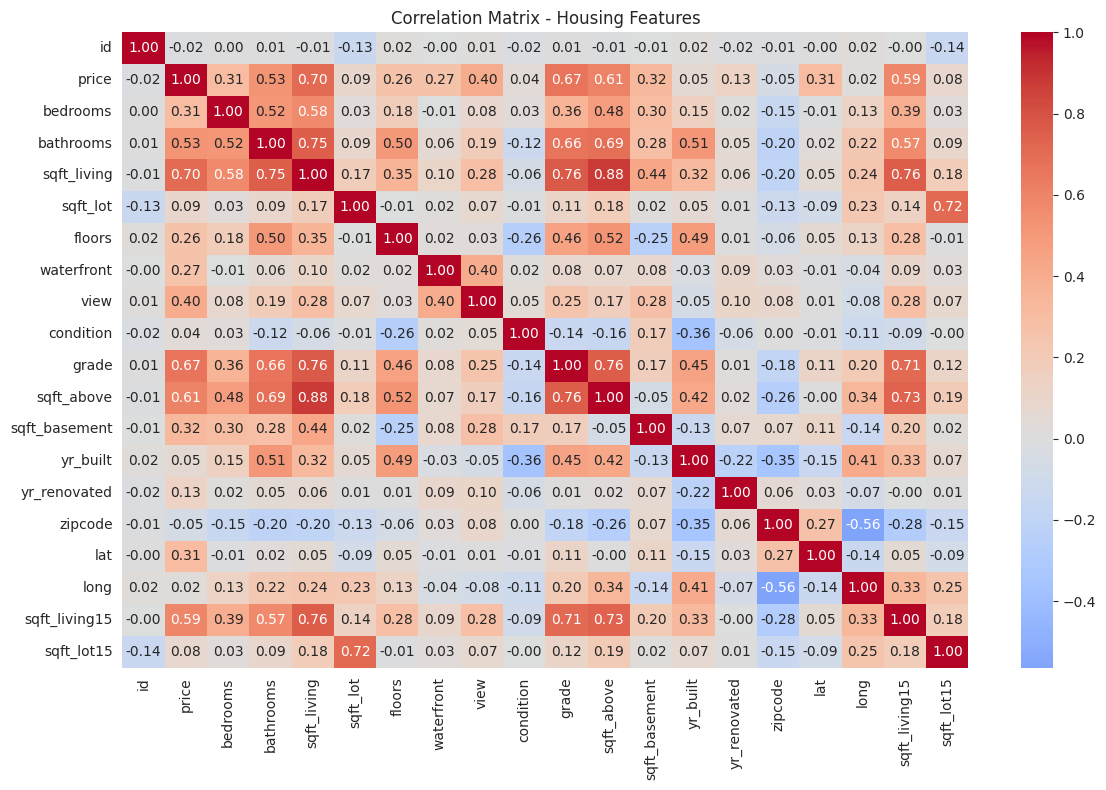

In [4]:
# Cell 1: Markdown
# Housing Data Exploration
# This notebook explores the variables in the Housing dataset and performs initial data analysis.

# Cell 2: Python - Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")

# Cell 3: Python - Load Data
df = pd.read_csv('../data/raw/Housing.csv')
print(f"Dataset shape: {df.shape}")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")

# Cell 4: Python - First Look
df.head()

# Cell 5: Python - Data Info
df.info()

# Cell 6: Python - Missing Values
missing = df.isnull().sum()
print("Missing values:\n", missing[missing > 0] if missing.sum() > 0 else "No missing values!")

# Cell 7: Python - Statistics
df.describe()

# Cell 8: Python - Correlation Analysis
# Cell 8: Python - Correlation Analysis (Numeric Only)
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])
correlation_with_price = numeric_df.corr()['price'].sort_values(ascending=False)
print("Correlation with Price:\n", correlation_with_price)
# Cell 9: Python - Correlation Heatmap
# Cell 9: Python - Correlation Heatmap (Numeric Only)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Housing Features')
plt.tight_layout()
plt.show()